In [ ]:
import os
import keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

: 

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
print(tf.__version__)

2.19.0


In [4]:
# Construct Distiller() class
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super(Distiller, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(self,optimizer,metrics,student_loss_fn,distillation_loss_fn,alpha=0.5, temperature=3):
        super(Distiller, self).compile(optimizer=optimizer, metrics=metrics, loss=student_loss_fn)
        self.optimizer = optimizer
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        with tf.GradientTape(persistent=True) as tape:
            teacher_logits = self.teacher(x, training=True)
            student_logits = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_logits)
            distillation_loss = self.distillation_loss_fn(tf.nn.softmax(teacher_logits / self.temperature), tf.nn.softmax(student_logits / self.temperature)) * (self.temperature ** 2)
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss
            self._loss_tracker.update_state(loss)

        student_gradients = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(student_gradients, self.student.trainable_variables))
        return self.compute_metrics(x, y, student_logits)
    
    def test_step(self, data):
        x, y = data
        with tf.GradientTape(persistent=True) as tape:
            teacher_logits = self.teacher(x, training=False)
            student_logits = self.student(x, training=False)
            student_loss = self.student_loss_fn(y, student_logits)
            distillation_loss = self.distillation_loss_fn(tf.nn.softmax(teacher_logits / self.temperature), tf.nn.softmax(student_logits / self.temperature)) * (self.temperature ** 2)
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss
            self._loss_tracker.update_state(loss)
        return self.compute_metrics(x, y, student_logits)

    def call(self, x):
        return self.student(x)

In [5]:
# Define directories
train_dir = "/home/bryan/Skin Cancer/Annotated/train"
val_dir = "/home/bryan/Skin Cancer/Annotated/valid"
test_dir = "/home/bryan/Skin Cancer/Annotated/test"

# Load datasets
batch_size = 16
img_size = (224, 224)  # Change based on your dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size
)

# Normalize images (convert to float and scale)
# train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
# val_ds = val_ds.map(lambda x, y: (x / 255.0, y))
# test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

Found 10941 files belonging to 3 classes.


I0000 00:00:1749038310.380844     775 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1039 files belonging to 3 classes.
Found 519 files belonging to 3 classes.


In [ ]:
# Load pre-trained teacher (DenseNet)
base_teacher = keras.applications.DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Create a new model with dropout
teacher_input = keras.Input(shape=(224, 224, 3))
x = base_teacher(teacher_input)  # Pass input through pre-trained layers
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64)(x)
teacher_output = layers.Dense(3)(x)
teacher = keras.Model(inputs=teacher_input, outputs=teacher_output)

In [7]:
# Load pre-trained MobileNetV2 without top layer
base_student = keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Train all layer
for layer in base_student.layers:
    layer.trainable = True

# Build the custom top of the student model
student_input = keras.Input(shape=(224, 224, 3))
y = base_student(student_input)
y = layers.GlobalAveragePooling2D()(y)
y = layers.Dense(64)(y)
student_output = layers.Dense(3)(y)
student = keras.Model(inputs=student_input, outputs=student_output)

In [8]:
# from keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='val_loss',  # Monitor validation loss
#     patience=5,          # Stop after 5 epochs with no improvement
#     restore_best_weights=True  # Restore weights from the best epoch
# )

In [8]:
# Train teacher as usual
teacher.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


# Train and evaluate teacher on data.
teacher.fit(train_ds, validation_data=val_ds, epochs=50)#, callbacks=[early_stopping])
teacher.evaluate(test_ds)

Epoch 1/50


I0000 00:00:1749038340.568736    1147 service.cc:152] XLA service 0x7febc0015290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749038340.568807    1147 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2025-06-04 18:59:01.358464: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749038344.025136    1147 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-06-04 18:59:06.616735: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25304', 60 bytes spill stores, 128 bytes spill loads

2025-06-04 18:59:06.964326: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fus

683/684 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.8036 - sparse_categorical_accuracy: 0.6805

2025-06-04 19:01:49.460191: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25304', 104 bytes spill stores, 104 bytes spill loads

2025-06-04 19:01:49.854373: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25304', 3956 bytes spill stores, 3940 bytes spill loads

2025-06-04 19:01:49.948136: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25304', 996 bytes spill stores, 996 bytes spill loads



684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.8033 - sparse_categorical_accuracy: 0.6806

2025-06-04 19:03:02.990236: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3292', 104 bytes spill stores, 104 bytes spill loads

2025-06-04 19:03:03.283838: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3292', 3940 bytes spill stores, 3932 bytes spill loads

2025-06-04 19:03:03.335467: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3292', 996 bytes spill stores, 996 bytes spill loads



684/684 ━━━━━━━━━━━━━━━━━━━━ 273s 265ms/step - loss: 0.8031 - sparse_categorical_accuracy: 0.6807 - val_loss: 0.5491 - val_sparse_categorical_accuracy: 0.7690
Epoch 2/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 90s 131ms/step - loss: 0.4041 - sparse_categorical_accuracy: 0.8341 - val_loss: 0.5455 - val_sparse_categorical_accuracy: 0.7931
Epoch 3/50
170/684 ━━━━━━━━━━━━━━━━━━━━ 58s 115ms/step - loss: 0.2787 - sparse_categorical_accuracy: 0.8889

KeyboardInterrupt: 

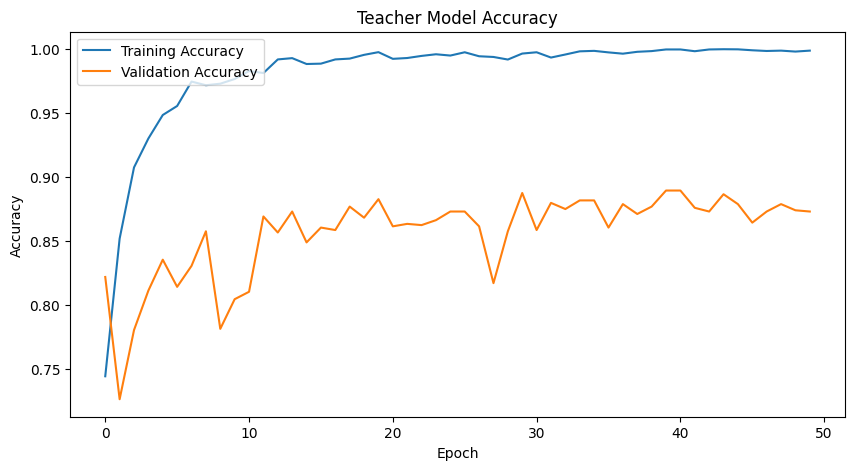

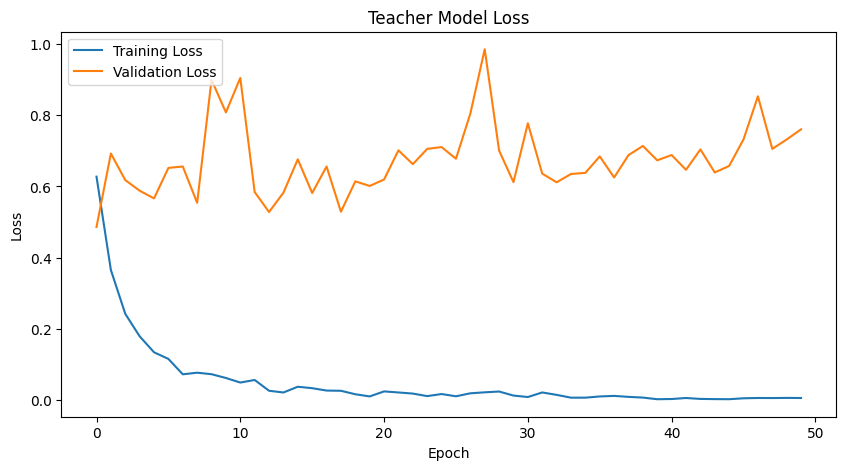

In [9]:
import matplotlib.pyplot as plt

# Assuming the training history of the teacher model is stored in `teacher.history`
# Extract the training and validation accuracy and loss
history = teacher.history.history  # Access the history dictionary

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Teacher Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Teacher Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate the student_scratch model on the test dataset
y_true = []
y_pred = []

# Collect true labels and predictions
for images, labels in test_ds:
    predictions = teacher.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(tf.argmax(predictions, axis=1).numpy())

# Calculate precision, recall, and F1 score
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━

2025-05-26 11:00:07.430304: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


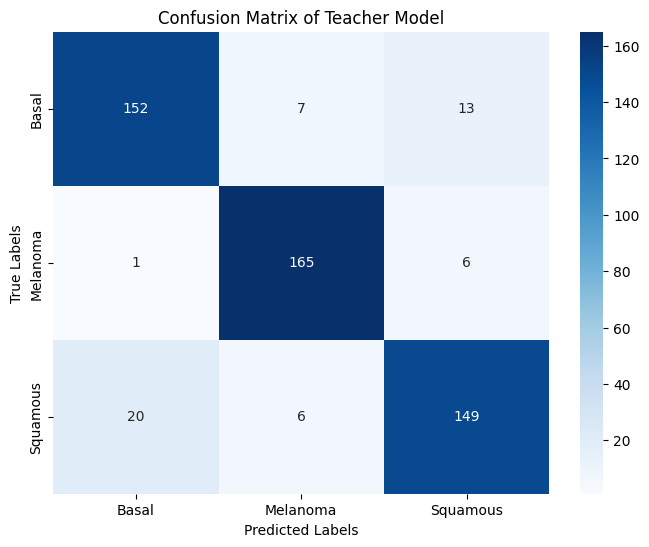

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Basal', 'Melanoma', 'Squamous'], yticklabels=['Basal', 'Melanoma', 'Squamous'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Teacher Model')
plt.show()

In [12]:
# Initialize and compile distiller
distiller = Distiller(student=student, teacher=teacher)
distiller.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.5,
    temperature=3,
)

# Distill teacher to student
distiller.fit(train_ds, validation_data=val_ds, epochs=50)#, callbacks=[early_stopping])

# Evaluate student on test dataset
distiller.evaluate(test_ds)

Epoch 1/50


2025-05-26 11:01:09.722799: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5628', 116 bytes spill stores, 116 bytes spill loads

2025-05-26 11:01:10.220762: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5628', 5616 bytes spill stores, 5612 bytes spill loads

2025-05-26 11:01:10.287576: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5628', 5372 bytes spill stores, 5352 bytes spill loads



683/684 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 3.4502 - sparse_categorical_accuracy: 0.6701

2025-05-26 11:02:31.731412: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5628', 104 bytes spill stores, 104 bytes spill loads

2025-05-26 11:02:32.322784: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5628', 5176 bytes spill stores, 5168 bytes spill loads

2025-05-26 11:02:32.450366: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5628', 5332 bytes spill stores, 5392 bytes spill loads



684/684 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 3.4495 - sparse_categorical_accuracy: 0.6702

2025-05-26 11:03:18.252057: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1779', 104 bytes spill stores, 104 bytes spill loads

2025-05-26 11:03:18.612801: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1779', 5460 bytes spill stores, 5500 bytes spill loads

2025-05-26 11:03:18.720321: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1779', 5304 bytes spill stores, 5304 bytes spill loads



684/684 ━━━━━━━━━━━━━━━━━━━━ 160s 145ms/step - loss: 3.4487 - sparse_categorical_accuracy: 0.6702 - val_loss: 16.5162 - val_sparse_categorical_accuracy: 0.3609
Epoch 2/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - loss: 2.1315 - sparse_categorical_accuracy: 0.8044 - val_loss: 8.2488 - val_sparse_categorical_accuracy: 0.5149
Epoch 3/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - loss: 1.6634 - sparse_categorical_accuracy: 0.8553 - val_loss: 5.3908 - val_sparse_categorical_accuracy: 0.6939
Epoch 4/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - loss: 1.3721 - sparse_categorical_accuracy: 0.8797 - val_loss: 7.0573 - val_sparse_categorical_accuracy: 0.5987
Epoch 5/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - loss: 1.0863 - sparse_categorical_accuracy: 0.9078 - val_loss: 3.7223 - val_sparse_categorical_accuracy: 0.6987
Epoch 6/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - loss: 0.8812 - sparse_categorical_accuracy: 0.9305 - val_loss: 4.4696 - val_sparse_categorical_accuracy: 0.7113


2025-05-26 11:37:35.730287: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1779', 104 bytes spill stores, 104 bytes spill loads

2025-05-26 11:37:36.064523: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1779', 4916 bytes spill stores, 4964 bytes spill loads

2025-05-26 11:37:36.153244: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1779', 4516 bytes spill stores, 4504 bytes spill loads



33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 314ms/step - loss: 0.9415 - sparse_categorical_accuracy: 0.8919


[0.9678456783294678, 0.884393036365509]

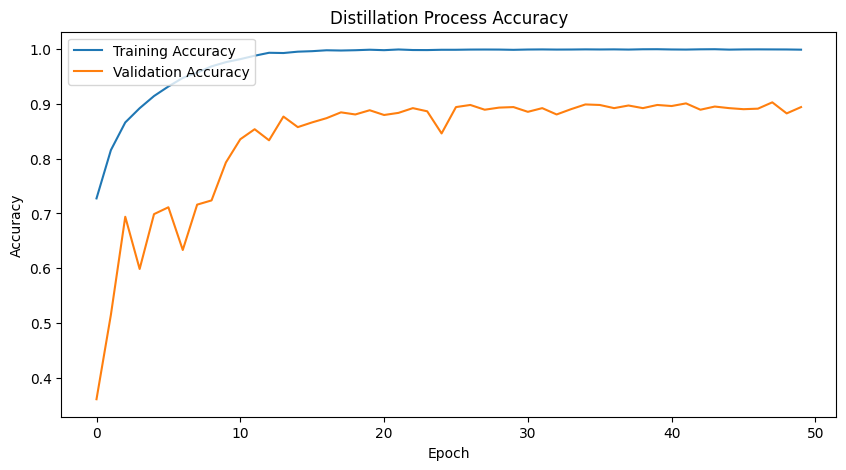

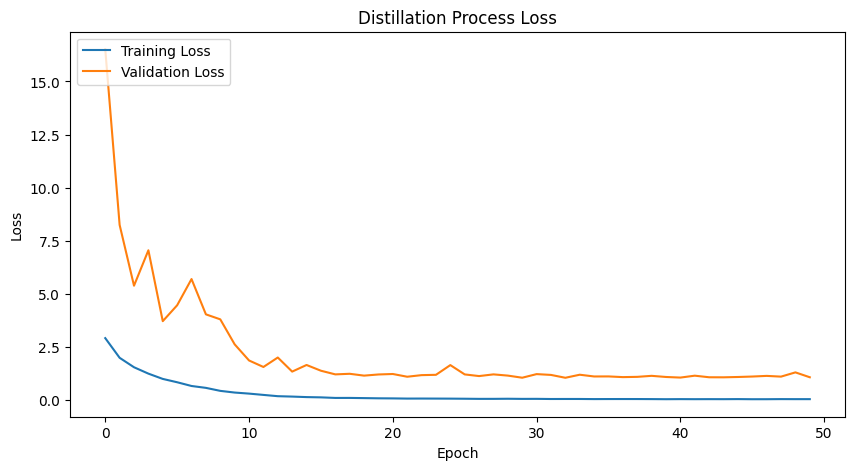

In [13]:
# Assuming the training history of the distillation process is stored in `distiller.history`
# Extract the training and validation accuracy and loss
distillation_history = distiller.history.history  # Access the history dictionary

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(distillation_history['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(distillation_history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Distillation Process Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(distillation_history['loss'], label='Training Loss')
plt.plot(distillation_history['val_loss'], label='Validation Loss')
plt.title('Distillation Process Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate the distiller model on the test dataset
y_true_distillation = []
y_pred_distillation = []

# Collect true labels and predictions
for images, labels in test_ds:
    predictions = distiller.predict(images)
    y_true_distillation.extend(labels.numpy())
    y_pred_distillation.extend(tf.argmax(predictions, axis=1).numpy())

# Calculate precision, recall, and F1 score
precision_distillation = precision_score(y_true_distillation, y_pred_distillation, average='weighted')
recall_distillation = recall_score(y_true_distillation, y_pred_distillation, average='weighted')
f1_distillation = f1_score(y_true_distillation, y_pred_distillation, average='weighted')

print(f"Precision (Distillation): {precision_distillation}")
print(f"Recall (Distillation): {recall_distillation}")
print(f"F1 Score (Distillation): {f1_distillation}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

2025-05-26 15:50:10.571932: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


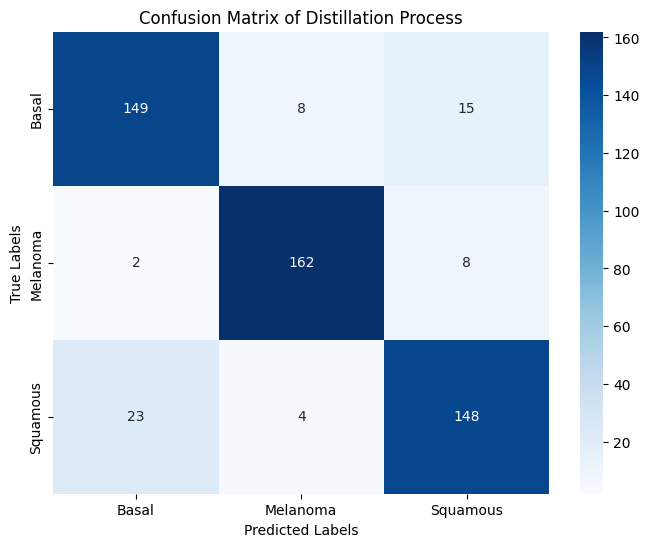

In [15]:
# Generate the confusion matrix for the distillation process
cm_distillation = confusion_matrix(y_true_distillation, y_pred_distillation)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_distillation, annot=True, fmt='d', cmap='Blues', xticklabels=['Basal', 'Melanoma', 'Squamous'], yticklabels=['Basal', 'Melanoma', 'Squamous'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Distillation Process')
plt.show()

In [16]:
# Save the distilled student model to a file
student.save('distilled_student_model(8).keras')

In [16]:
#Clone student for later comparison
student_scratch = keras.models.clone_model(student)

# Train student as done usually
student_scratch.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)



# Train and evaluate student trained from scratch.
student_scratch.fit(train_ds, validation_data=val_ds, epochs=50)#, callbacks=[early_stopping])
student_scratch.evaluate(test_ds)

Epoch 1/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 52s 51ms/step - loss: 1.0061 - sparse_categorical_accuracy: 0.4849 - val_loss: 1.1056 - val_sparse_categorical_accuracy: 0.3340
Epoch 2/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - loss: 0.8873 - sparse_categorical_accuracy: 0.5732 - val_loss: 1.1256 - val_sparse_categorical_accuracy: 0.3340
Epoch 3/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - loss: 0.8528 - sparse_categorical_accuracy: 0.5980 - val_loss: 1.1851 - val_sparse_categorical_accuracy: 0.3340
Epoch 4/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - loss: 0.8226 - sparse_categorical_accuracy: 0.6146 - val_loss: 1.2377 - val_sparse_categorical_accuracy: 0.3340
Epoch 5/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - loss: 0.7963 - sparse_categorical_accuracy: 0.6375 - val_loss: 1.3997 - val_sparse_categorical_accuracy: 0.3340
Epoch 6/50
684/684 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - loss: 0.7798 - sparse_categorical_accuracy: 0.6445 - val_loss: 1.5599 - val_sparse_categorical_accuracy:

[1.3175930976867676, 0.69749516248703]

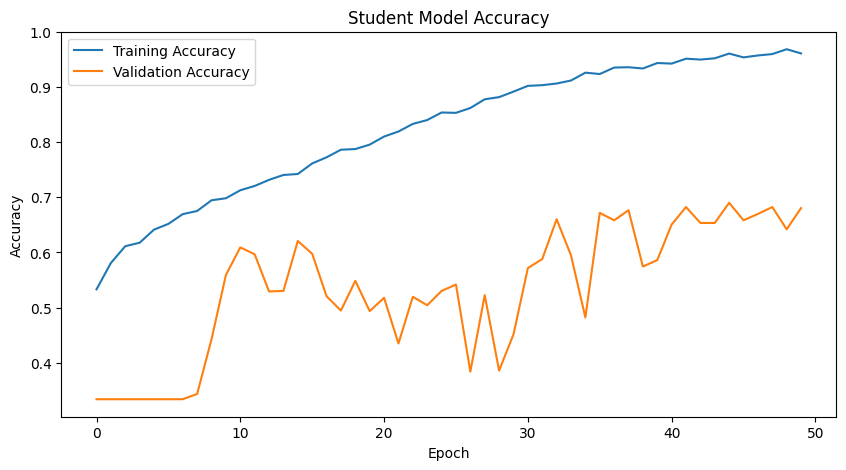

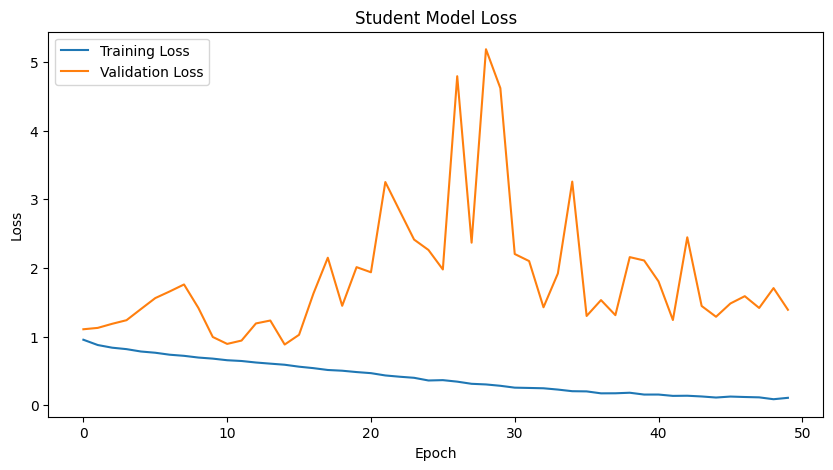

In [17]:
# Assuming the training history of the student model is stored in `student_scratch.history`
# Extract the training and validation accuracy and loss
student_history = student_scratch.history.history  # Access the history dictionary

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(student_history['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(student_history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Student Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(student_history['loss'], label='Training Loss')
plt.plot(student_history['val_loss'], label='Validation Loss')
plt.title('Student Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate the student_scratch model on the test dataset
y_true_student = []
y_pred_student = []

for images, labels in test_ds:
    preds = student_scratch.predict(images)
    y_true_student.extend(labels.numpy())
    y_pred_student.extend(tf.argmax(preds, axis=1).numpy())

precision_student = precision_score(y_true_student, y_pred_student, average='weighted')
recall_student = recall_score(y_true_student, y_pred_student, average='weighted')
f1_student = f1_score(y_true_student, y_pred_student, average='weighted')

print(f"Precision (Student Scratch): {precision_student}")
print(f"Recall (Student Scratch): {recall_student}")
print(f"F1 Score (Student Scratch): {f1_student}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━

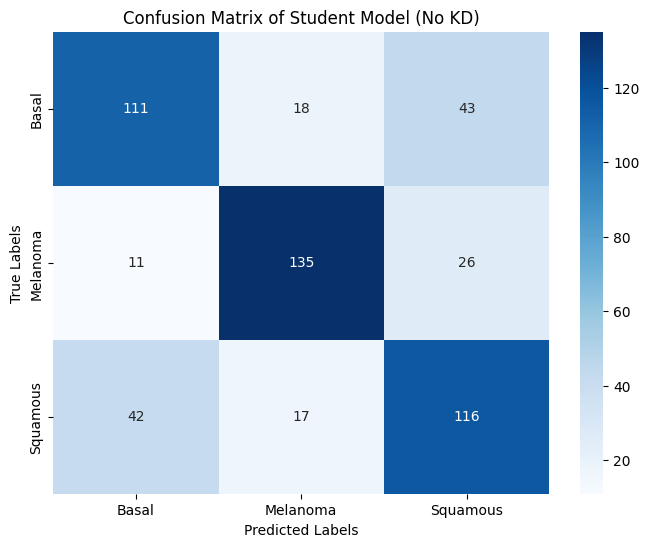

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate the confusion matrix for the student model trained without KD
cm_student = confusion_matrix(y_true_student, y_pred_student)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_student, annot=True, fmt='d', cmap='Blues', xticklabels=['Basal', 'Melanoma', 'Squamous'], yticklabels=['Basal', 'Melanoma', 'Squamous'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Student Model (No KD)')
plt.show()

In [12]:
# Evaluate the student_scratch model on the test dataset
results = student_scratch.evaluate(test_ds, verbose=0)

# Get the metric names from the model
metric_names = student_scratch.metrics_names

# Print the metric scores
for metric_name, score in zip(metric_names, results):
  print(f'{metric_name}: {score}')

loss: 1.709255576133728
compile_metrics: 0.7302504777908325


In [14]:
# Save the student model to an HDF5 file
student.save('student_model.keras')

# If you want to save in TensorFlow SavedModel format:
# student.save('student_model_saved', save_format='tf')